# derive posteriors for each simulated galaxy using NPE

We want "realistic" posteriors for each simulated galaxy in `mock0`. To do this we'll use neural posterior estimation (NPE). 

The data generation is simple: 
```
mock_Muv_1sig = 0.2 + 0.17*np.random.normal(size=mock.shape[0]).clip(0.1, None) 
mock_Muv = mock[:,1] + mock_Muv_1sig * np.random.normal(size=mock.shape[0])

mock_photoz_1sig = (0.45 + 0.35 * np.random.normal(size=mock.shape[0])).clip(0.05, None) 
mock_photoz = mock[:,0] + mock_photoz_1sig * np.random.normal(size=mock.shape[0])
```
so we can easily construct a perfect training dataset and get near optimal posteriors. 

In [1]:
import numpy as np

In [2]:
import torch
from sbi.inference import NPE

In [3]:
import corner as DFM
import matplotlib.pyplot as plt

In [4]:
Nsample = 20000
_Muv_true = np.random.uniform(-14, -24, size=Nsample)
_z_true = np.random.uniform(4, 15, size=Nsample)

_Muv_1sig = 0.2 + 0.17*np.random.normal(size=Nsample).clip(0.1, None) 
_z_1sig = 0.45 + 0.35 * np.random.normal(size=Nsample).clip(0.05, None) 

_Muv_train = _Muv_true + _Muv_1sig * np.random.normal(size=Nsample)
_z_train = _z_true + _z_1sig * np.random.normal(size=Nsample)

In [5]:
theta = np.vstack([_Muv_true, _z_true]).T
X = np.vstack([_Muv_train, _z_train, _Muv_1sig, _z_1sig]).T

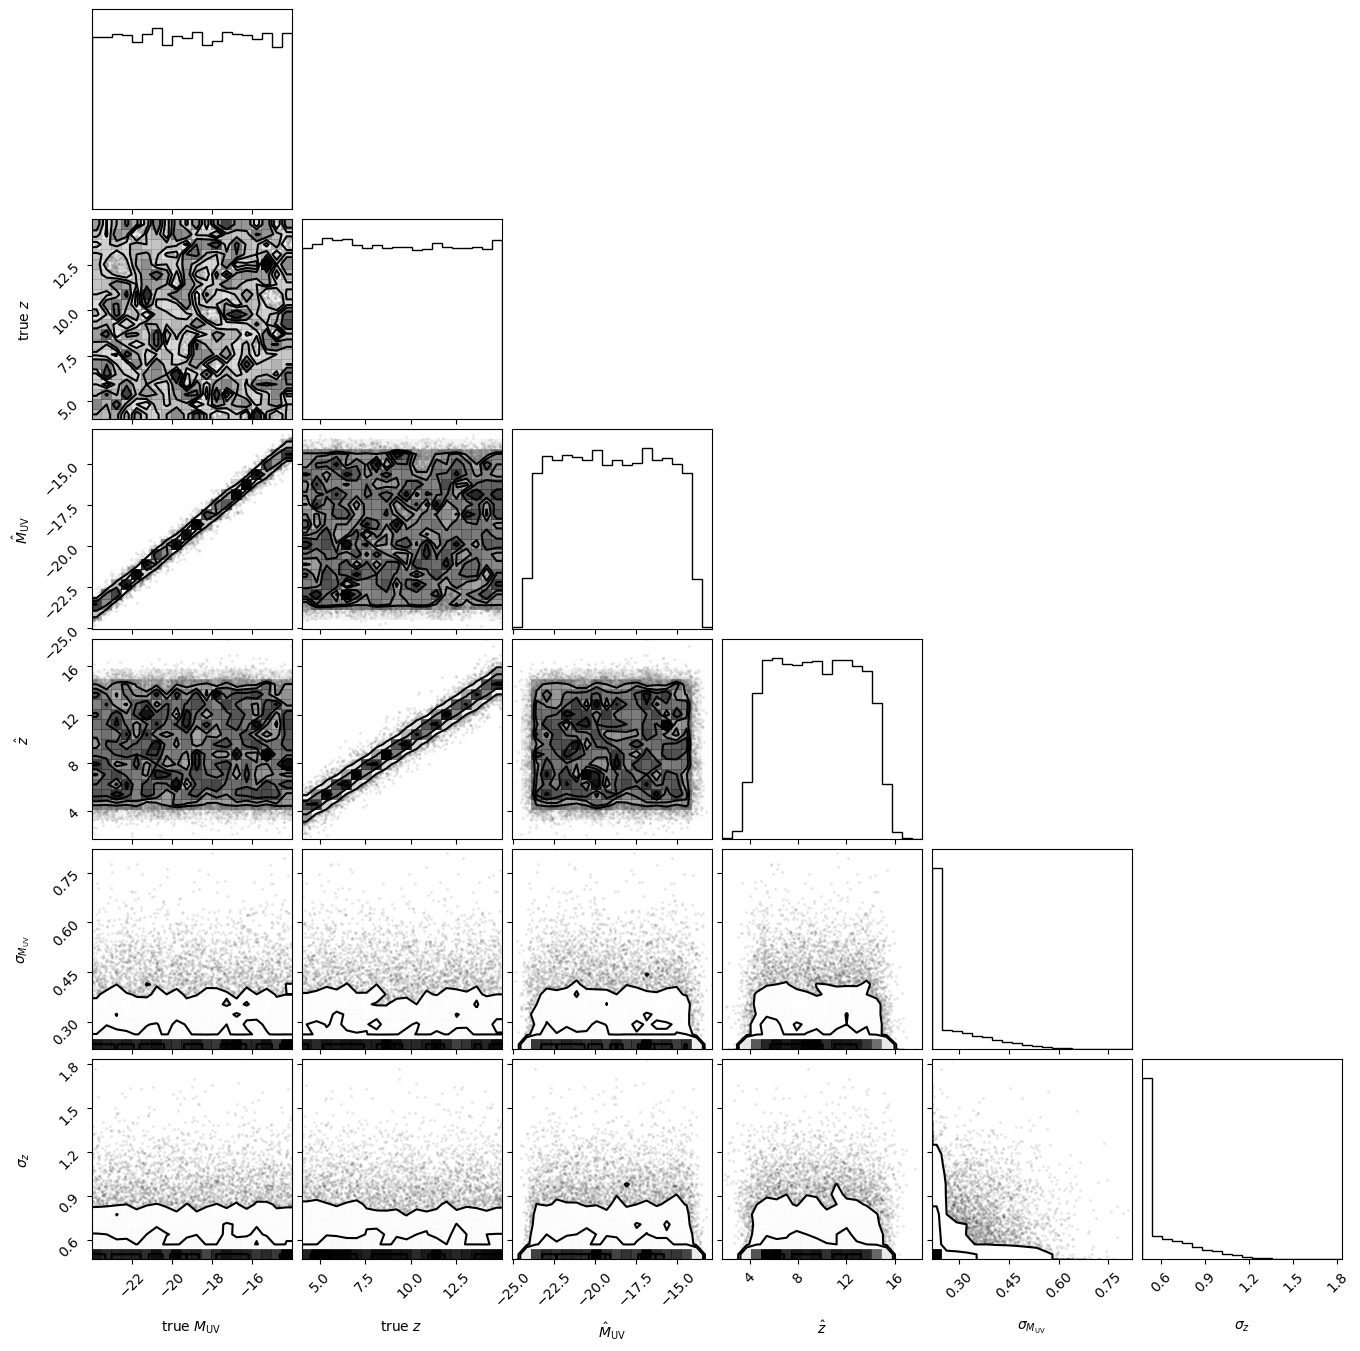

In [6]:
fig = DFM.corner(np.hstack([theta, X]),
           labels=[r'true $M_{\rm UV}$', 'true $z$', 
                   r'$\hat{M}_{\rm UV}$', r'$\hat{z}$', 
                   r'$\sigma_{M_{\rm UV}}$', r'$\sigma_{z}$'])

## train NPE

In [7]:
ishuffle = np.arange(theta.shape[0])
np.random.shuffle(ishuffle)

In [8]:
_theta = torch.tensor(theta[ishuffle][:int(theta.shape[0]*0.9)].astype(np.float32))
_X = torch.tensor(X[ishuffle][:int(theta.shape[0]*0.9)].astype(np.float32))

In [15]:
inference = NPE(density_estimator='maf', device=torch.device("mps"))
posterior_net = inference.append_simulations(_theta, _X).train()

/opt/homebrew/Caskroom/miniconda/base/envs/jwst/lib/python3.14/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Data x has device 'cpu'. Moving x to the data_device 'mps'. Training will proceed on device 'mps'.
  theta, x = validate_theta_and_x(
/opt/homebrew/Caskroom/miniconda/base/envs/jwst/lib/python3.14/site-packages/sbi/inference/trainers/npe/npe_base.py:184: UserWarning: Parameters theta has device 'cpu'. Moving theta to the data_device 'mps'. Training will proceed on device 'mps'.
  theta, x = validate_theta_and_x(


 Neural network successfully converged after 125 epochs.

In [16]:
posterior = inference.build_posterior()

/opt/homebrew/Caskroom/miniconda/base/envs/jwst/lib/python3.14/site-packages/sbi/inference/potentials/posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


## validate NPE

In [19]:
test_theta = torch.tensor(theta[ishuffle][int(theta.shape[0]*0.9):].astype(np.float32)).to(torch.device("mps"))
test_X = torch.tensor(X[ishuffle][int(theta.shape[0]*0.9):].astype(np.float32)).to(torch.device("mps"))

  0%|          | 0/10000 [00:00<?, ?it/s]

[-20.308609  10.024244]
tensor([-20.1785,  10.4116])


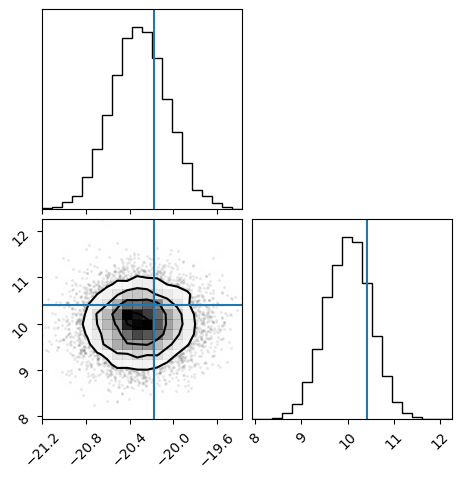

  0%|          | 0/10000 [00:00<?, ?it/s]

[-22.991884  14.483419]
tensor([-23.7726,  14.5232])


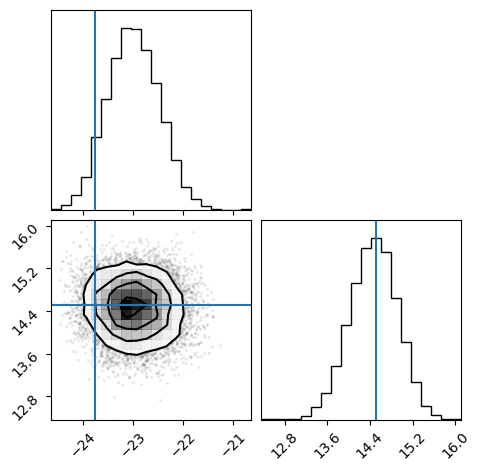

  0%|          | 0/10000 [00:00<?, ?it/s]

[-18.469807   9.846685]
tensor([-18.5006,  10.0821])


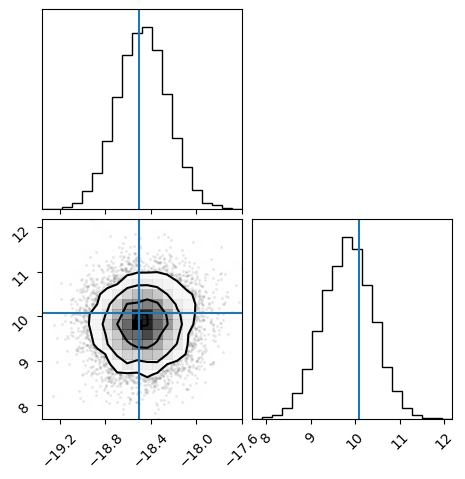

In [23]:
for i in range(3):
    samples = posterior.sample((10000,), x=test_X[i]).cpu()
    print(np.median(samples, axis=0))
    print(test_theta[i].cpu())
    
    fig = DFM.corner(samples.numpy())
    DFM.overplot_lines(fig, test_theta[i].cpu())
    plt.show()

In [24]:
test_samples = posterior.sample_batched((1000,), x=test_X, show_progress_bars=False)

/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_34240/697222158.py:1: UserWarning: Capping max_sampling_batch_size from 10000 to 50 to avoid excessive memory usage.
  test_samples = posterior.sample_batched((1000,), x=test_X, show_progress_bars=False)


In [25]:
import tarp

In [27]:
ecp, alpha = tarp.get_tarp_coverage(test_samples.cpu().numpy(), test_theta.cpu().numpy())

Text(0.5, 0, 'Credibility Level')

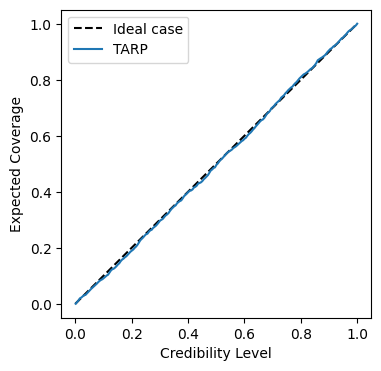

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot([0, 1], [0, 1], ls='--', color='k', label = "Ideal case")
ax.plot(alpha, ecp, label='TARP')
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")

In [47]:
torch.save(posterior, '/Users/chang/data/px2cosmo/mock0_npe.pt')

# deploy on `mock0`

In [30]:
_, _, mock_photoz, mock_Muv, mock_photoz_1sig, mock_Muv_1sig, _, _ = np.loadtxt('/Users/chang/data/px2cosmo/mock0.dat',
                                                                    unpack=True, skiprows=1)

In [34]:
X_obs = torch.tensor(np.vstack([mock_Muv, mock_photoz, mock_photoz_1sig, mock_Muv_1sig]).T.astype(np.float32)).to('mps')

In [35]:
samples_obs = posterior.sample_batched((10000,), x=X_obs, show_progress_bars=False)

/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_34240/3898987496.py:1: UserWarning: Note that for batched sampling, the direct posterior sampling generates 888 * 10000 = 8880000 samples. This can be slow and memory-intensive. Consider reducing the number of samples or batch size.
  samples_obs = posterior.sample_batched((10000,), x=X_obs, show_progress_bars=False)
/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_34240/3898987496.py:1: UserWarning: Capping max_sampling_batch_size from 10000 to 112 to avoid excessive memory usage.
  samples_obs = posterior.sample_batched((10000,), x=X_obs, show_progress_bars=False)


In [38]:
X_obs.shape

torch.Size([888, 4])

In [39]:
samples_obs.shape

torch.Size([10000, 888, 2])

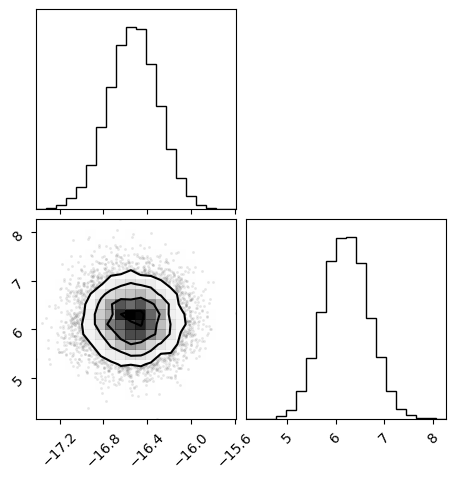

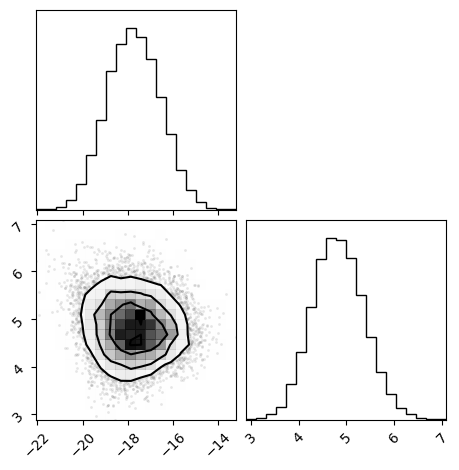

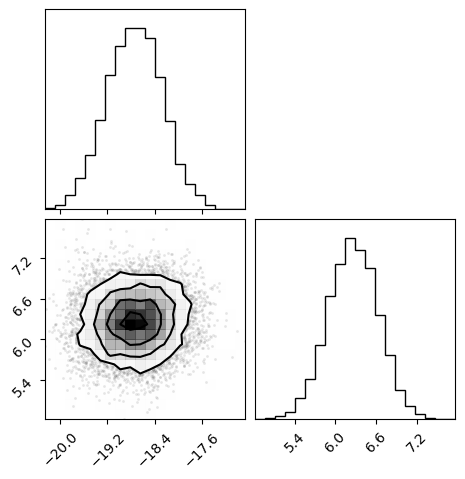

In [40]:
# check a few posteriors
for igal in range(3): 
    fig = DFM.corner(samples_obs.cpu().numpy()[:,igal,:])
    plt.show()

In [44]:
np.save('/Users/chang/data/px2cosmo/mock0_posteriors.dat', 
        np.transpose(samples_obs.cpu().numpy(), (1, 0, 2)))